# Modeling type of charts to represents concrete degrad

## Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [36]:
def momento_resistente_secao_sem_cor(a_s: float, b_w: float, h: float, f_ck: float, f_yk: float = 500000, gamma_s: float = 1.15, gamma_c: float = 1.40) -> float:
    """
    Calcula o momento resistente para vigas de concreto armado.

    Args:
        f_ck: resistência característica à compressão do concreto (em kPa)
        a_s: área da armadura longitudinal (em mm²)
        b_w: largura da seção transversal (em mm)
        h: altura total da seção transversal (em mm)

    Returns:
        m_rd: valor do momento resistente limite utilizando armadura simples (em N.mm)
    """

    f_ck /= 1E3
    if f_ck > 50:
        lambdaa = 0.80 - ((f_ck - 50) / 400)
        alpha_c = (1.00 - ((f_ck - 50) / 200)) * 0.85
    else:
        lambdaa = 0.80
        alpha_c = 0.85

    f_ck *= 1E3
    f_cd = f_ck / gamma_c
    d = h * 0.9
    f_yd = f_yk / gamma_s
    x = ((a_s * f_yd) / (f_cd * b_w * alpha_c * lambdaa))
    m_rd = a_s * f_yd * (d - x * 0.5 * lambdaa)
    return m_rd

## Modeling

Load dataset

In [37]:
dfaux = pd.read_excel(r'C:\Users\wande\OneDrive\Documentos\GitHub\ic_victor\final_df_tempo_limite_lhspequeno.xlsx')
df = dfaux.head(1)
df

,b_w,h,f_ck,m_rd,m_gk,m_qk,a_s,time
0,0.14,0.3,20000,9.836582,6.323517,0.702613,0.000076,47.180765


Define the number os samples

In [56]:
n = 20 # 20000

In [59]:
results_mr = []
results_as = []
for i, row in df.iterrows():
    b_w = row['b_w']
    h = row['h']
    f_ck = row['f_ck']
    f_yk = 500E3
    m_gk = row['m_gk']
    m_qk = row['m_qk']
    a_saux = row['a_s']
    # Sampling
    for j in range(n):
        m_r_list = []
        f_ck = np.random.normal(f_ck, 0.12 * f_ck)
        f_yk = np.random.normal(f_yk, 0.05 * f_yk)
        m_gk = np.random.normal(1.06 * m_gk, 0.15 * 1.06 * m_gk)
        for k in range(0, 101, 10):
            m_qk = np.random.gumbel(0.93 * m_qk, 0.25 * 0.93 * m_qk)
            if k < 39:
                degrad = 1
            else:
                a_d = 1
                b_d = 0.000055
                degrad = a_d * (1 - b_d * k ** 2)
            a_scor = a_saux * degrad
            m_r = momento_resistente_secao_sem_cor(a_scor, b_w, h, f_ck, f_yk, gamma_s=1.00, gamma_c=1.00)
            m_r_list.append(m_r)
        results_mr.append(m_r_list)

plots

- chart resistent bending moment

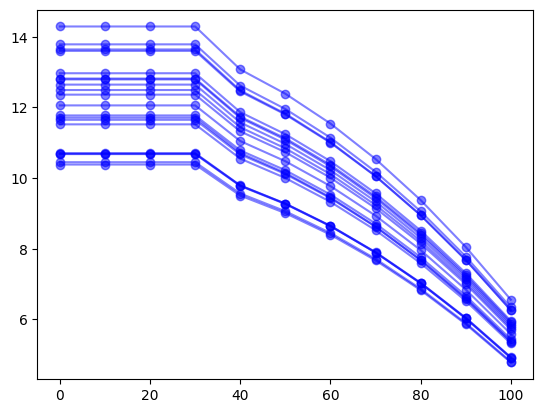

In [60]:
x = list(np.arange(0, 101, 10))
# chart results_mr versus x
for l in results_mr:
    # Tamanho do gráfico
    plt.plot(x, l, marker='o', linestyle='-', color='b', alpha=0.5) # scatter plot, cor cinza com transparência para ficar clarinho
    # edição do gráfico: label, tamanho label

- chart steel reinforcement degrad

In [ ]:
x = list(np.arange(0, 101, 10))
# chart results_mr versus x
for l in results_mr:
    # Tamanho do gráfico
    plt.plot(x, l, marker='o', linestyle='-', color='b', alpha=0.5) # scatter plot, cor cinza com transparência para ficar clarinho
    # edição do gráfico: label, tamanho label

In [ ]:
# m_r_list

[np.float64(9.492350261097572),
 np.float64(9.441403538771608),
 np.float64(9.288479671973445),
 np.float64(9.033327561242247),
 np.float64(8.675528707476637),
 np.float64(8.21449721193468),
 np.float64(7.649479776233884),
 np.float64(6.979555702351214),
 np.float64(6.203636892623075),
 np.float64(5.320467849745325),
 np.float64(4.3286256767732585)]

In [ ]:
# results_mr

[[np.float64(9.983257088206445),
  np.float64(9.929787739923855),
  np.float64(9.769284224652377),
  np.float64(9.501460131120922),
  np.float64(9.125838107210999),
  np.float64(8.641749859956716),
  np.float64(8.048336155544796),
  np.float64(7.344546819314554),
  np.float64(6.529140735757921),
  np.float64(5.6006858485194195),
  np.float64(4.55755916039618)],
 [np.float64(9.525640905702197),
  np.float64(9.474515442101644),
  np.float64(9.32105506230939),
  np.float64(9.065007799353708),
  np.float64(8.705953708281674),
  np.float64(8.24330486615923),
  np.float64(7.676305372071138),
  np.float64(7.004031347121002),
  np.float64(6.2253909344312675),
  np.float64(5.339124299143211),
  np.float64(4.343803628416947)],
 [np.float64(9.492350261097572),
  np.float64(9.441403538771608),
  np.float64(9.288479671973445),
  np.float64(9.033327561242247),
  np.float64(8.675528707476637),
  np.float64(8.21449721193468),
  np.float64(7.649479776233884),
  np.float64(6.979555702351214),
  np.float